In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("./FACTors.csv")

In [4]:
df.keys()

Index(['row_id', 'article_id', 'claim_id', 'claim', 'date_published', 'author',
       'organisation', 'original_verdict', 'title', 'url',
       'normalised_rating'],
      dtype='object')

In [5]:
df['date_published']

0         2024-12-12T00:00:00
1         2024-12-12T00:00:00
2         2024-12-13T00:00:00
3         2024-12-13T00:00:00
4         2024-11-22T00:00:00
                 ...         
118107    2022-10-04T20:29:56
118108    2022-10-05T19:50:42
118109    2022-10-05T21:15:28
118110    2022-10-05T21:07:54
118111    2022-09-24T21:04:07
Name: date_published, Length: 118112, dtype: object

In [6]:
# Check the format of date_published
print("Sample dates:")
print(df['date_published'].head(10))
print("\nData type:", df['date_published'].dtype)
print("\nTotal records:", len(df))

Sample dates:
0    2024-12-12T00:00:00
1    2024-12-12T00:00:00
2    2024-12-13T00:00:00
3    2024-12-13T00:00:00
4    2024-11-22T00:00:00
5    2024-11-25T00:00:00
6    2024-11-25T00:00:00
7    2024-11-26T00:00:00
8    2024-11-26T00:00:00
9    2024-11-27T00:00:00
Name: date_published, dtype: object

Data type: object

Total records: 118112


In [7]:
# Convert date_published to datetime and count records since 2017
df['date_published'] = pd.to_datetime(df['date_published'], errors='coerce')

# Filter data published since 2017 (including 2017)
since_2017 = df[df['date_published'] >= '2020-01-01']

print(f"Total records in dataset: {len(df)}")
print(f"Records published since 2020: {len(since_2017)}")
print(f"Percentage: {len(since_2017)/len(df)*100:.2f}%")
print(f"\nYear distribution:")
print(df['date_published'].dt.year.value_counts().sort_index())

Total records in dataset: 118112
Records published since 2020: 82572
Percentage: 69.91%

Year distribution:
date_published
1995        1
1996       17
1997       35
1998       99
1999      173
2000      340
2001      350
2002      234
2003      264
2004      277
2005      243
2006      285
2007      278
2008      401
2009      438
2010      404
2011     1574
2012     2402
2013     1940
2014     2473
2015     2667
2016     4652
2017     3778
2018     4310
2019     7905
2020    13791
2021    15670
2022    15831
2023    15981
2024    20951
2025      348
Name: count, dtype: int64


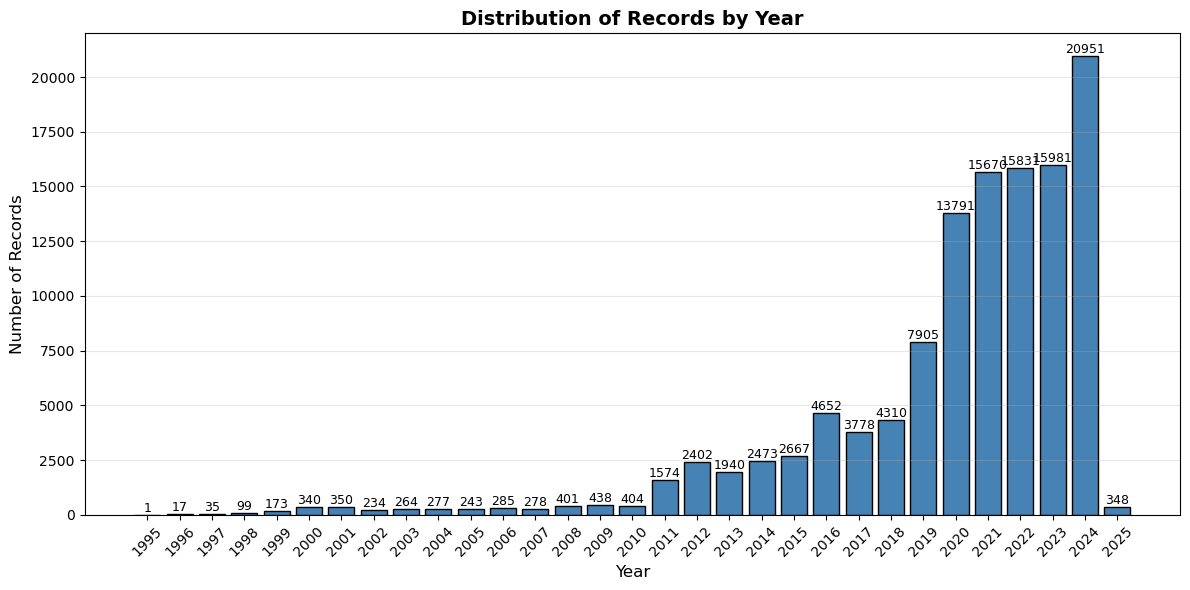


Year with most records: 2024 (20951 records)
Year with least records: 1995 (1 records)


In [8]:
import matplotlib.pyplot as plt

# Plot year distribution
year_counts = df['date_published'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.title('Distribution of Records by Year', fontsize=14, fontweight='bold')
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for year, count in zip(year_counts.index, year_counts.values):
    plt.text(year, count, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nYear with most records: {year_counts.idxmax()} ({year_counts.max()} records)")
print(f"Year with least records: {year_counts.idxmin()} ({year_counts.min()} records)")

In [9]:
# Explore the full structure of the dataset
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("Column Names and Data Types:")
print("="*80)
print(df.dtypes)
print("\n" + "="*80)
print("First Few Rows:")
print("="*80)
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print("="*80)
df.info()
print("\n" + "="*80)
print("Missing Values:")
print("="*80)
print(df.isnull().sum())
print("\n" + "="*80)
print("Sample Record:")
print("="*80)
print(df.iloc[0].to_dict())

Dataset Shape: (118112, 11)

Column Names and Data Types:
row_id                        int64
article_id                    int64
claim_id                      int64
claim                        object
date_published       datetime64[ns]
author                       object
organisation                 object
original_verdict             object
title                        object
url                          object
normalised_rating            object
dtype: object

First Few Rows:
   row_id  article_id  claim_id  \
0       1       49808      2977   
1       2       49837      1828   
2       3       49532      2978   
3       4       50339      2979   
4       5       49038      2980   

                                               claim date_published  \
0  "Allahu Akbar" has replaced" Cheerio, mate!" a...     2024-12-12   
1      Elon Musk has announced a Tesla mobile phone.     2024-12-12   
2  It takes 30,000 tonnes of concrete and 30,000 ...     2024-12-13   
3  A video reveals t